## Creating RC class and training RC

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np


class ReservoirComputer: #class makes it easy to train and test multiple models without reinitializing global variables.
    
    def __init__(self, Nx, Nu, Ny,
                 alpha=0.9, spectral_radius=0.9, density=0.05,
                 ridge=1e-6, seed=None):                     #self refers to the specific instance of the class we're working with
                                                             #init automatically runs when you create a new instance of a class. so i will create rc1 = RC(Nx =, Nu =,...) and these will automatically be assigned to self.Nx, self.Nu,... 
        rng = np.random.default_rng(seed)                    #used to generate the internal random weights (Win, W, etc.) reproducibly.
        self.Nx, self.Nu, self.Ny = Nx, Nu, Ny               #Nx = number of neurons in reservoir, Nu = number of inputs, Ny = number of outputs
        self.alpha, self.ridge = alpha, ridge                #alpha = leak rate, ridge = lambda in ridge regression calculation
        self.Win = rng.uniform(-1, 1, size=(Nx, 1 + Nu))    #taking values from unif(-1,1) to scale it, if had taken unif(-10,10) say, then values would all be at +-1 when apply tanh
        W = rng.uniform(-1, 1, size=(Nx, Nx))               #going to make W sparse and then scale to desired spectral radius             
        W *= (rng.random((Nx, Nx)) < density)               #rng.random creates matrix of random values between 0 and 1, shape (Nx,Nx) same as W. then saying < density makes it a boolean matrix, so all values are either true or false, depending on if they are respectively < density or not. Multiplying this by W, when multiplyiny by true its same as 1, false is 0
        eigmax = max(1e-12, np.max(np.abs(np.linalg.eigvals(W))))  #safeguards against math crashing if the eigvalues are all really close to 0, can happen due to random initialisation
        self.W = (spectral_radius / eigmax) * W              #largest eigenvalue of W will now be equal to the spectral radius specified by user
        self.Wout = None  

    def step(self, x, u):  #update step for x - given previous x and previous u, step function gives next x
        x_tilde = np.tanh(self.Win @ np.concatenate(([1.0], u)) + self.W @ x) #multiply Win by bias and input (total input signal that each neuron receives from outside world+bias), add it to the current matrix multiplied by x (what each neuron receives from other neurons)
        return (1 - self.alpha) * x + self.alpha * x_tilde
                                       
    def run_reservoir(self, U, x0=None): #applying the step function to all the input, collecting the feature vectors. U is a time series of input vectors shape (T, Nu)
        T = len(U)              #no of timesteps T = the length of U, the input
        X = np.zeros((T, self.Nx))  #stores all reservoir states across time. If have 100 timesteps, 500 neurons, then shape = (100,500)
        x = np.zeros(self.Nx) if x0 is None else x0 #current reservoir state at each step. so its the state of each neuron, so if have 500 neuros, x will have length 500. if we are not given an initial state, then just start with all 0s
        for t in range(T):
            x = self.step(x, U[t])  #U[t]: input at time step t, allows for vectors
            X[t] = x                
        return X
                                    #washing out the first 10 steps so reservoir forgets initial state. Note Ytarget is the output we want
    def train(self, U, Ytarget, washout=10): #training Wout by ridge regression adds a lambda||Wout||^2 term, penalises large weights and prevents overfitting
        X = self.run_reservoir(U)
        bias = np.ones((len(U), 1))  #vertical vector of 1s - T (=lenU) rows and 1 column
        Z = np.hstack([bias, U, X])  #stacking the features into an array, shape (T, 1+Nu+Nx)
        Z, Ytarget = Z[washout:], Ytarget[washout:] #getting rid of first washout steps, so reservoir can forget its initial 0 state
        I = np.eye(Z.shape[1])       # identity matrix of size Z.shape[1]- meaning the number of columns of Z = 1+Nu+Nx
        self.Wout = np.linalg.solve(Z.T @ Z + self.ridge * I, Z.T @ Ytarget).T  #ridge formula
        return self

    def predict(self, U_test, K): #predict k steps after warmup sequence
        x0 = np.zeros(self.Nx) 
        X = self.run_reservoir(U_test, x0 = x0)
        bias = np.ones((len(U_test),1))
        Z = np.hstack([bias, U_test, X])
        Yhat = Z@self.Wout.T
        x_last = X[-1]
        y_last = Yhat[-1] #taking the final reservoir state and input from test sequence, to be used to start prediction loop
        Y_future = np.zeros((K,self.Ny))
        for k in range(K):
            x_next = self.step(x_last, y_last)
            z_next = np.hstack([1.0, y_last, x_next])
            y_next = z_next@ self.Wout.T
            Y_future[k] = y_next
            x_last = x_next
            y_last = y_next
        return Y_future 

    def autonomous_step(self, x_last, y_last): #the mapping from the previous reservoir state and output to the next reservoir state and output
        x_next = self.step(x_last, y_last)
        z = np.hstack([1.0, y_last, x_next])
        y_next = z@self.Wout.T
        return x_next, y_next

    def autonomous_run(self, x0, y0, n_steps): #given an initial x0 and y0, will run the reservoir for n_steps autonomously, returning X and Y
        X = np.zeros((n_steps, self.Nx))
        Y = np.zeros((n_steps, self.Ny))
        for i in range(n_steps):
            x,y = self.autonomous_step(x0, y0)
            X[i] = x
            Y[i] = y
            x0 = x
            y0 = y
        return X, Y

#train reservoir on the following training sequence - logistic map
r = 3.8 #control parameter, = 3.8 for chaotic behaviour
T = 300 #number of steps
s = np.zeros(T + 1) 
s[0] = 0.5  # initial condition
for n in range(1,T+1): #generate logistic map sequence
    s[n] = r * s[n-1] * (1 - s[n-1])
U = s[:-1][:,None] #rc expects 2D matrix with shape (T,Nu), meaning a column vector, with each row an input. But x is just a horizontal vector of values, so [:, None] turns it in to shape we need
Ytarget = s[1:][:,None] #similarly, changing from a horizontal vector to column vector to get shape (T,Ny) instead of (T,)
#training reservoir
rc = ReservoirComputer(Nx=400, Nu=1, Ny=1, alpha=0.8,
                           spectral_radius=0.9, density=0.05,
                           ridge=1e-6, seed=1)
rc.train(U=U, Ytarget=Ytarget)
        

## Lorenz system

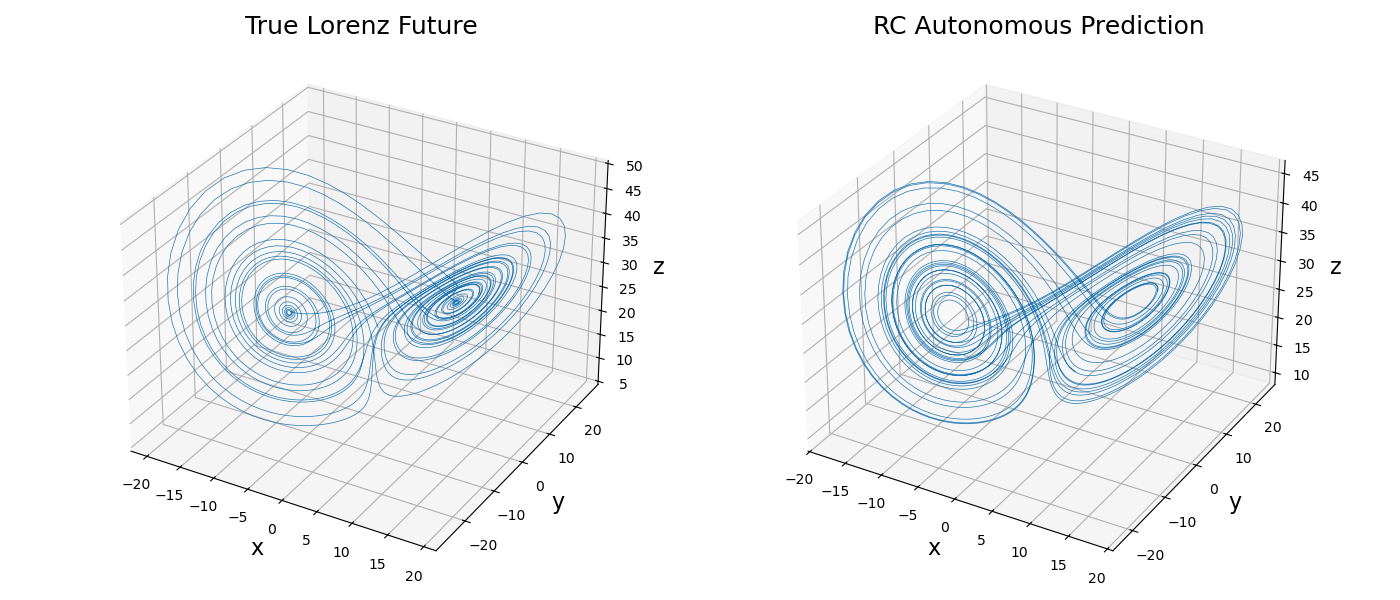

In [2]:
#Lorenz

#making sequence for training
def lorenz_rhs(x, y, z, sigma, rho, beta): #defining the equations on the rhs of the lorenz ode
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return dx, dy, dz #so given the current state (x,y,z) it returns the derivatives (dx,dy,dz)
    
def euler_v(f, init_state, dt, T, *params): #turns the ode in to a discrete trajectory by stepping forward in time
    N = int(np.ceil(T / dt))                #np.ceil rounds up, N is the number of discrete time steps, int converts to an integer
    t = dt * np.arange(N + 1)               #the array of time numbers
    dim = len(init_state)                   #dimension of the system - for lorenze init_state = (x0,y0,z0) => dim 3
    traj = np.empty((N + 1, dim))           #denote X by traj as have too many X's. empty array for the trajectory - N+1 (time) rows, 3 columsn (as dim =3 for lorenz)
    traj[0] = init_state                    #first row of the trajectory is the initial condition
    for n in range(N):                      #for each row will be doing the below
        derivs = f(*traj[n], *params)       #*traj[n] unpacks the elements of traj[n] in to different parameters. *params passes system parameters (sigma rho and bets)
        traj[n + 1] = traj[n] + dt * np.array(derivs) #this is the euler update step. x(n+1) =x(n)+dt(x.(n))
    return t, traj                          #function integrates the ode using euler, turning it in to a discrete trajectory

#values
sigma, rho, beta = 10.0, 28.0, 8.0/3.0
dt, T = 1e-2, 40.0
x0, y0, z0 = 1.0, 1.0, 1.0
t, traj = euler_v(lorenz_rhs, (x0, y0, z0), dt, T, sigma, rho, beta)
U = traj[:-1]        #the usual one-step ahead map
Y = traj[1:]         
#normalizing to stop prediction error blowing up - one coordinate may dominate training otherwise
mu = U.mean(axis=0)
std = U.std(axis=0)
U_n = (U-mu)/std
Y_n = (Y-mu)/std
rc = ReservoirComputer(Nx=564, Nu=3, Ny=3, alpha=0.9326634798211147, spectral_radius=0.9288868155097104, density=0.014279791357581456, ridge=1e-6, seed=0)
rc.train(U_n, Y_n)

#making sequence for testing
#just need different initial conditions
x0_test, y0_test, z0_test = 1.1, 1.0, 1.0   # slightly different IC
t_test, traj_test = euler_v(lorenz_rhs, (x0_test, y0_test, z0_test), dt, T, sigma, rho, beta)
warmup = traj_test[:500]   # give it true data to set internal state
warmup_n = (warmup-mu)/std #normalising warmup for prediction
K = len(traj_test) - 500                   # how far to predict freely
Y_future_norm = rc.predict(warmup_n, K)
Y_future = Y_future_norm*std+mu #denormalise again
true_future = traj_test[500:500+K]

#plotting to evaluate
fig1 = plt.figure(figsize=(14, 6))
ax1 = fig1.add_subplot(121, projection="3d")
ax1.plot(true_future[:, 0], true_future[:, 1], true_future[:, 2], lw=0.5)
ax1.set_xlabel("x", fontsize=16); ax1.set_ylabel("y", fontsize=16); ax1.set_zlabel("z", fontsize=16)
ax1.set_title("True Lorenz Future", fontsize = 18)
ax2 = fig1.add_subplot(122, projection="3d")
ax2.plot(Y_future[:, 0], Y_future[:, 1], Y_future[:, 2], lw=0.5)
ax2.set_xlabel("x", fontsize=16); ax2.set_ylabel("y", fontsize=16); ax2.set_zlabel("z", fontsize=16)
ax2.set_title("RC Autonomous Prediction", fontsize = 18)
plt.tight_layout()
plt.savefig("lorenz_3d.png", dpi=600, bbox_inches="tight")
plt.show()